# Domaining geológico

Antes de entrenar modelos especializados por tipo de depósito necesitamos saber si tiene sentido. Acá respondemos:

1. ¿Cuántos depósitos hay por `Deposit_type`? (masa crítica para un XGB dedicado)
2. ¿Son las distribuciones de Cu realmente distintas entre tipos? (si son iguales, domaining no suma)
3. ¿Los rangos de tonelaje/edad cambian entre tipos? (justifica features distintas por dominio)

Decisión: basados en estos números definimos la estrategia (un modelo por tipo grande + "otros", o híbrido global+local).

## 1. Cargar datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

DATA_DIR = "../data/external/Global-copper-deposit-dataset/"
df_main = pd.read_excel(DATA_DIR + "Global_Copper_Deposit_Main.xlsx")
df = df_main.dropna(subset=["Copper_grade(Cu; %)"]).copy()
print(f"Depósitos con Cu: {len(df)}")

Depósitos con Cu: 989


## 2. Conteo por tipo de depósito

Necesitamos saber la masa crítica. Regla práctica: por debajo de ~80-100 depósitos, un XGB dedicado va a overfittear.

In [2]:
type_counts = df["Deposit_type"].value_counts()
print("Registros por Deposit_type:")
print(type_counts)
print(f"\nTotal: {len(df)}")
print(f"Tipos únicos: {df['Deposit_type'].nunique()}")
print(f"Nulos en Deposit_type: {df['Deposit_type'].isnull().sum()}")

Registros por Deposit_type:
Deposit_type
VMS                 425
Porphyry            395
Sediment-Hosted     104
Magmatic sulfide     36
IOCG                 29
Name: count, dtype: int64

Total: 989
Tipos únicos: 5
Nulos en Deposit_type: 0


## 3. Distribución de Cu por tipo

Si las medianas y rangos son similares entre tipos, el domaining no suma mucho. Si son muy distintos (ej: VMS con medianas 2x las de Porphyry), sí tiene sentido separar.

In [3]:
cu_stats = df.groupby("Deposit_type")["Copper_grade(Cu; %)"].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max',
     lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]
).round(3)
cu_stats.columns = ['n', 'mean', 'median', 'std', 'min', 'max', 'q25', 'q75']
cu_stats = cu_stats.sort_values('n', ascending=False)
print("Estadísticas de Cu (%) por tipo:")
print(cu_stats)

Estadísticas de Cu (%) por tipo:
                    n   mean  median    std    min    max    q25    q75
Deposit_type                                                           
VMS               425  1.824   1.400  1.390  0.080  10.00  0.970  2.350
Porphyry          395  0.475   0.440  0.219  0.070   1.76  0.340  0.565
Sediment-Hosted   104  2.444   2.000  1.948  0.300  13.00  1.105  3.015
Magmatic sulfide   36  0.388   0.285  0.345  0.029   1.69  0.182  0.472
IOCG               29  1.225   0.950  1.187  0.300   5.50  0.600  1.400


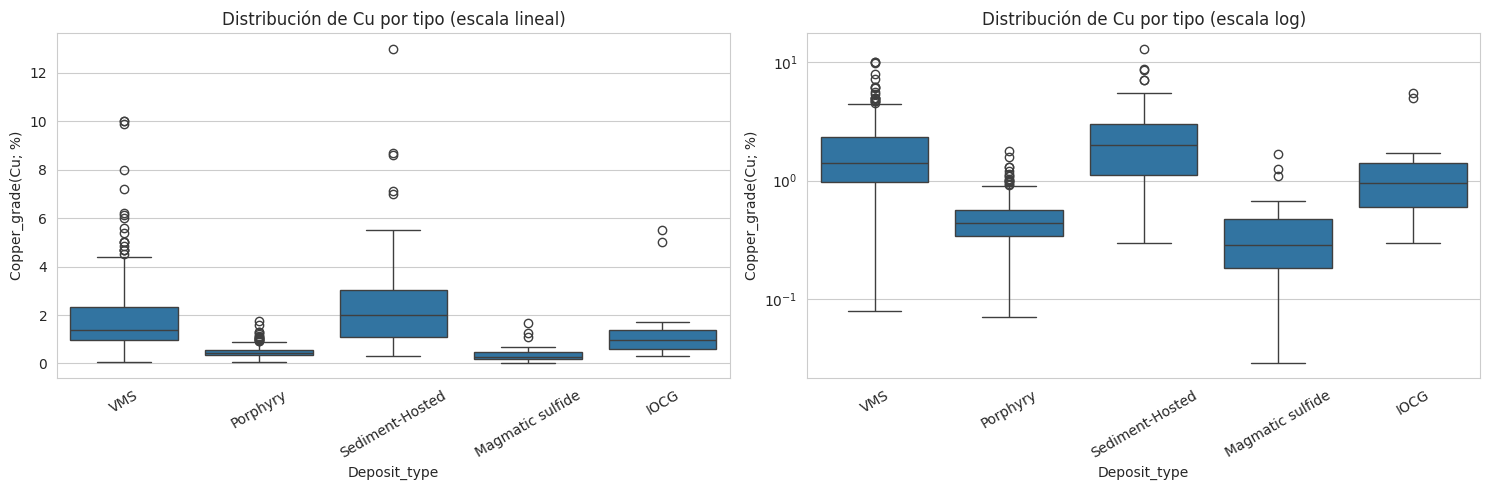

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_types = type_counts.index.tolist()
df_plot = df[df["Deposit_type"].isin(top_types)].copy()

sns.boxplot(data=df_plot, x="Deposit_type", y="Copper_grade(Cu; %)",
            order=top_types, ax=axes[0])
axes[0].set_title("Distribución de Cu por tipo (escala lineal)")
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_plot, x="Deposit_type", y="Copper_grade(Cu; %)",
            order=top_types, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Distribución de Cu por tipo (escala log)")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. Tonelaje y edad por tipo

Si los rangos de estas features cambian mucho por tipo, confirma que las relaciones aprendidas van a ser distintas en cada dominio.

In [5]:
ton_stats = df.groupby("Deposit_type")["Tonnage(Mt)"].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(2).sort_values('count', ascending=False)
print("Tonnage(Mt) por tipo:")
print(ton_stats)

print("\nMax_age(Ma) por tipo:")
age_stats = df.groupby("Deposit_type")["Max_age(Ma)"].agg(
    ['count', 'mean', 'median', 'std']
).round(1).sort_values('count', ascending=False)
print(age_stats)

Tonnage(Mt) por tipo:
                  count    mean  median      std   min       max
Deposit_type                                                    
VMS                 425   17.97    4.09    43.03  0.10    469.00
Porphyry            395  745.66  241.00  1992.02  4.40  21277.00
Sediment-Hosted     104  109.09   10.55   247.65  0.12   1370.00
Magmatic sulfide     30   41.26    7.48    97.29  0.28    519.75
IOCG                 27  561.80   66.00  1470.94  0.35   6700.00

Max_age(Ma) por tipo:
                  count    mean  median     std
Deposit_type                                   
VMS                 364  1044.1   445.0  1132.9
Porphyry            336   184.9    58.0   413.7
Sediment-Hosted      87   883.9   900.0   518.4
Magmatic sulfide     18   549.5   309.4   458.3
IOCG                 11  1725.7  1575.0   717.8


## 5. Test estadístico: ¿son las medias de Cu diferentes entre tipos?

Kruskal-Wallis (no asume normalidad). Si p < 0.05, rechazamos la hipótesis de que todas las distribuciones vienen del mismo proceso — hay diferencias reales por tipo y domaining tiene fundamento estadístico.

In [6]:
from scipy.stats import kruskal

groups = [df[df["Deposit_type"] == t]["Copper_grade(Cu; %)"].values
          for t in type_counts.index]
stat, pvalue = kruskal(*groups)
print(f"Kruskal-Wallis H = {stat:.2f}")
print(f"p-value = {pvalue:.2e}")
if pvalue < 0.05:
    print("\n→ Las distribuciones de Cu SÍ son significativamente distintas entre tipos.")
    print("  Domaining tiene fundamento estadístico.")
else:
    print("\n→ No hay evidencia de diferencia entre tipos.")

Kruskal-Wallis H = 539.25
p-value = 2.17e-115

→ Las distribuciones de Cu SÍ son significativamente distintas entre tipos.
  Domaining tiene fundamento estadístico.


## 6. Decisión de estrategia

Basado en las tablas de arriba, etiquetamos cada tipo según su masa crítica:
- **≥150 depósitos**: modelo XGBoost dedicado viable
- **50-149**: modelo dedicado riesgoso, preferir agrupar
- **<50**: agrupar en categoría "otros"

In [7]:
def strategy(n):
    if n >= 150: return "modelo dedicado"
    if n >= 50:  return "dedicado si EDA lo justifica, si no agrupar"
    return "agrupar en 'otros'"

plan = pd.DataFrame({
    "n": type_counts,
    "estrategia": type_counts.apply(strategy)
})
print(plan)

                    n                                   estrategia
Deposit_type                                                      
VMS               425                              modelo dedicado
Porphyry          395                              modelo dedicado
Sediment-Hosted   104  dedicado si EDA lo justifica, si no agrupar
Magmatic sulfide   36                           agrupar en 'otros'
IOCG               29                           agrupar en 'otros'
